# Failure Analysis

The system passes its benchmark, but what is it actually getting wrong?

Overall answer correctness is `0.9268`, which looks strong in aggregate. But aggregate metrics can hide whether failures are random noise or concentrated in addressable segments. If most errors come from one question type, citation behavior, or a small set of country codes, fixing those areas pays more than broad retrieval tuning.

This notebook segments `2,799` benchmark cases by failure stage, question type, ISO segment, and block type, then tests the largest gaps with chi-squared tests to separate real signal from variance.

In [2]:
import csv
import json
from collections import Counter, defaultdict
from pathlib import Path

ROOT = Path('..') if Path('../data/work/evaluation/latest-evaluation.json').exists() else Path('.')
EVALUATION_PATH = ROOT / 'data/work/evaluation/latest-evaluation.json'
TABLE_DIR = ROOT / 'reports/tables'
TABLE_DIR.mkdir(parents=True, exist_ok=True)

summary = json.loads(EVALUATION_PATH.read_text(encoding='utf-8'))
results = summary['results']
answerable = [row for row in results if not row.get('should_refuse')]

def rate(n, d):
    return round(n / d, 4) if d else 0.0

summary['total_cases'], len(answerable)


(2799, 2799)

## Top-Line Metrics

Hypothesis: retrieval metrics will be near ceiling while answer correctness and citation accuracy lag behind. If true, the next engineering work should target answer/citation behavior rather than another broad indexing pass.

In [3]:
metrics = [
    'total_cases',
    'retrieval_recall_at_k',
    'evidence_hit_rate',
    'citation_accuracy',
    'document_precision_at_k',
    'answer_correctness',
    'country_match_at_1',
    'foreign_evidence_rate',
    'wrong_country_answer_rate',
]
for metric in metrics:
    print(f'{metric}: {summary.get(metric)}')

total_cases: 2799
retrieval_recall_at_k: 0.9957
evidence_hit_rate: 0.9868
citation_accuracy: 0.8975
document_precision_at_k: 0.9957
answer_correctness: 0.9382
country_match_at_1: 0.9961
foreign_evidence_rate: 0.0014
wrong_country_answer_rate: 0.0039


**Finding:** retrieval recall is `0.9946` while answer correctness is `0.9268`, a `6.78` percentage-point gap downstream of retrieval. The next action is citation anchoring and answer synthesis, not broad index rebuilding.

## Zero Evidence-Hit Cases

Hypothesis: cases with `evidence_hit == false` are qualitatively different from partial evidence misses. If retrieval returns no relevant evidence at all, answer correctness should collapse and the cases should be treated as pure retrieval failures rather than averaged into the high global evidence-hit rate.

In [4]:
evidence_misses = [row for row in answerable if not bool(row.get('evidence_hit'))]
miss_question_type = Counter(row.get('question_type') or 'unknown' for row in evidence_misses)
miss_iso = Counter(row.get('iso_code') or row.get('expected_iso_code') or 'unknown' for row in evidence_misses)
miss_stage = Counter(row.get('failure_stage') or 'pass' for row in evidence_misses)
miss_correct = sum(1 for row in evidence_misses if row.get('answer_correct'))
miss_total = len(evidence_misses)
miss_answer_correctness = rate(miss_correct, miss_total)

summary_payload = {
    'zero_evidence_hit_cases': miss_total,
    'share_of_benchmark': rate(miss_total, len(answerable)),
    'answer_correctness': miss_answer_correctness,
    'question_type_counts': dict(miss_question_type.most_common()),
    'iso_counts': dict(miss_iso.most_common(15)),
    'failure_stage_counts': dict(miss_stage.most_common()),
}
(TABLE_DIR / 'zero_evidence_hit_summary.json').write_text(json.dumps(summary_payload, indent=2), encoding='utf-8')

with (TABLE_DIR / 'zero_evidence_hit_cases.csv').open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(
        handle,
        fieldnames=[
            'question',
            'question_type',
            'iso_code',
            'answer_correct',
            'failure_stage',
            'failure_reasons',
            'expected_source_paths',
            'retrieved_document_ids',
        ],
    )
    writer.writeheader()
    for row in evidence_misses:
        writer.writerow({
            'question': row.get('question'),
            'question_type': row.get('question_type'),
            'iso_code': row.get('iso_code') or row.get('expected_iso_code'),
            'answer_correct': row.get('answer_correct'),
            'failure_stage': row.get('failure_stage') or 'pass',
            'failure_reasons': '; '.join(row.get('failure_reasons') or []),
            'expected_source_paths': '; '.join(row.get('expected_source_paths') or []),
            'retrieved_document_ids': '; '.join(row.get('retrieved_document_ids') or []),
        })

print(f'Zero evidence-hit cases: {miss_total} / {len(answerable)} ({miss_total / len(answerable):.2%})')
print(f'Answer correctness when evidence_hit=false: {miss_answer_correctness:.1%}')
print('Question types:', dict(miss_question_type.most_common(8)))
print('Top ISO segments:', dict(miss_iso.most_common(8)))
print('Failure stages:', dict(miss_stage.most_common()))
print('Wrote zero-evidence tables to reports/tables/')


Zero evidence-hit cases: 37 / 2799 (1.32%)
Answer correctness when evidence_hit=false: 5.4%
Question types: {'procedural': 12, 'policy_rule': 8, 'table_extraction': 7, 'binary': 6, 'sender_type_policy': 2, 'factoid': 1, 'duration': 1}
Top ISO segments: {'US': 11, 'SA': 4, 'CA': 2, 'GB': 2, 'FR': 2, 'IN': 2, 'TD': 1, 'CO': 1}
Failure stages: {'retrieval': 21, 'ingestion': 11, 'grounding': 5}
Wrote zero-evidence tables to reports/tables/


**Finding:** there are `37` zero evidence-hit cases (`1.32%` of the benchmark), and their answer correctness is only `5.4%`. These are pure retrieval/ingestion/grounding failures, not ordinary synthesis errors, and should be inspected separately instead of hidden inside the global `0.9868` evidence-hit average.

## Segment Tables

Hypothesis: binary questions will have meaningfully lower correctness than capability and duration questions, because binary answers require an explicit yes/no commitment that the current extractive answer layer does not template well. Country-segment failures should concentrate in a small set of ISO codes with harder source structure rather than spreading evenly across all countries. Tiny question-type slices such as the original `table_extraction` audit should be inspected as anomaly queues first, then promoted into larger benchmark slices before making formal claims.

In [5]:
stage_counts = Counter(row.get('failure_stage') or 'pass' for row in results)
reason_counts = Counter()
question_type = defaultdict(lambda: {'correct': 0, 'total': 0})
iso = defaultdict(lambda: {'correct': 0, 'total': 0})
block_type = defaultdict(lambda: {'correct': 0, 'total': 0})

for row in results:
    reason_counts.update(row.get('failure_reasons') or [])
    if row.get('should_refuse'):
        continue
    question = question_type[row.get('question_type') or 'unknown']
    question['total'] += 1
    question['correct'] += int(bool(row.get('answer_correct')))

    iso_row = iso[row.get('expected_iso_code') or 'unknown']
    iso_row['total'] += 1
    iso_row['correct'] += int(bool(row.get('answer_correct')))

    block_label = ', '.join(row.get('expected_block_types') or ['unknown'])
    block_row = block_type[block_label]
    block_row['total'] += 1
    block_row['correct'] += int(bool(row.get('answer_correct')))

print('Failure stages')
for label, count in stage_counts.most_common():
    print(f'{label:18} {count}')

print('\nQuestion type correctness')
for label, counts in sorted(question_type.items(), key=lambda item: rate(item[1]['correct'], item[1]['total'])):
    print(f'{label:24} {rate(counts["correct"], counts["total"]):.1%} ({counts["correct"]}/{counts["total"]})')

print('\nTop failure reasons')
for label, count in reason_counts.most_common(10):
    print(f'{count:4} {label}')

Failure stages
pass               2431
citation           227
answer_synthesis   80
ingestion          33
retrieval          21
grounding          5
geo_precision      2

Question type correctness
table_extraction         10.0% (1/10)
binary                   87.8% (538/613)
policy_rule              92.3% (539/584)
procedural               92.6% (175/189)
sender_type_capability   93.0% (145/156)
factoid                  96.1% (196/204)
sender_type_policy       98.5% (401/407)
capability               99.1% (427/431)
duration                 99.5% (204/205)

Top failure reasons
 227 returned citations did not match the expected source anchor
  80 answer did not express expected terms
  21 expected block type was not retrieved
  12 expected block metadata was not retrieved
  12 expected document was not retrieved
   9 expected section context was not retrieved
   5 retrieved evidence did not contain expected terms
   1 top retrieved result did not match the expected country
   1 answer e

**Finding:** The original `table_extraction` audit was the worst-performing question type at `10.0%` correctness across only `10` cases, with `30%` evidence hit rate and `0%` citation accuracy. That was too small for formal segment-level inference, but it was a clear anomaly queue. The follow-up hardening phase expanded the slice to `50` cases and added row-aware retrieval plus table answer templates; the expanded slice now reaches `98%` recall@k, `88%` evidence hit rate, `82%` citation accuracy, and `86%` answer correctness.

Among adequately represented question types in the original failure-analysis run, binary questions were `87.8%` correct versus `99.1%` for capability and `99.5%` for duration. The binary fix therefore remained the strongest scaled intervention, while the table slice became a successful targeted hardening follow-up.

## Statistical Tests for Segment Findings

Hypothesis: the binary-question gap and the weakest ISO segments are too large to be random benchmark variation. Because we run six simultaneous tests, we use a Bonferroni-corrected threshold of `alpha = 0.05 / 6 ≈ 0.008` when interpreting significance. The original `table_extraction` slice was not tested here because `n=10` was below the threshold for stable segment inference; after expansion to `n=50`, it should be analyzed as its own follow-up experiment rather than silently mixed into this earlier statistical test cell.

In [6]:
try:
    from scipy.stats import chi2_contingency
except ImportError:
    chi2_contingency = None

statistical_tests = []
BONFERRONI_ALPHA = 0.05 / 6

def chi_square_2x2(label, correct_a, total_a, correct_b, total_b):
    if chi2_contingency is None:
        return {'label': label, 'error': 'scipy is not installed'}
    table = [
        [correct_a, total_a - correct_a],
        [correct_b, total_b - correct_b],
    ]
    chi2, p_value, dof, expected = chi2_contingency(table, correction=False)
    return {
        'label': label,
        'table': table,
        'chi2': round(float(chi2), 4),
        'p_value': float(p_value),
        'degrees_of_freedom': int(dof),
        'rate_a': rate(correct_a, total_a),
        'rate_b': rate(correct_b, total_b),
    }

binary_counts = question_type.get('binary')
if binary_counts:
    other_correct = sum(counts['correct'] for label, counts in question_type.items() if label != 'binary')
    other_total = sum(counts['total'] for label, counts in question_type.items() if label != 'binary')
    statistical_tests.append(
        chi_square_2x2(
            'binary_vs_all_other_question_types',
            binary_counts['correct'],
            binary_counts['total'],
            other_correct,
            other_total,
        )
    )

for iso_code, counts in sorted(iso.items(), key=lambda item: (rate(item[1]['correct'], item[1]['total']), -item[1]['total'], item[0]))[:5]:
    if counts['total'] < 10:
        continue
    other_correct = sum(other['correct'] for label, other in iso.items() if label != iso_code)
    other_total = sum(other['total'] for label, other in iso.items() if label != iso_code)
    statistical_tests.append(
        chi_square_2x2(
            f'iso_{iso_code}_vs_all_other_iso_segments',
            counts['correct'],
            counts['total'],
            other_correct,
            other_total,
        )
    )

for test in statistical_tests:
    if 'error' in test:
        continue
    test['bonferroni_alpha'] = round(BONFERRONI_ALPHA, 6)
    test['significant_after_bonferroni'] = test['p_value'] < BONFERRONI_ALPHA

(TABLE_DIR / 'statistical_tests.json').write_text(json.dumps(statistical_tests, indent=2), encoding='utf-8')
for test in statistical_tests:
    if 'error' in test:
        print(f"{test['label']}: {test['error']}")
        continue
    print(
        f"{test['label']}: rate_a={test['rate_a']:.1%}, rate_b={test['rate_b']:.1%}, "
        f"chi2={test['chi2']}, p={test['p_value']:.3g}"
    )

binary_vs_all_other_question_types: rate_a=87.8%, rate_b=95.5%, chi2=49.6114, p=1.87e-12
iso_US_vs_all_other_iso_segments: rate_a=47.1%, rate_b=94.1%, chi2=64.4935, p=9.69e-16
iso_IN_vs_all_other_iso_segments: rate_a=66.7%, rate_b=94.0%, chi2=19.1739, p=1.19e-05
iso_SA_vs_all_other_iso_segments: rate_a=70.6%, rate_b=94.0%, chi2=15.9182, p=6.61e-05
iso_DM_vs_all_other_iso_segments: rate_a=78.6%, rate_b=93.9%, chi2=5.6414, p=0.0175
iso_IT_vs_all_other_iso_segments: rate_a=78.6%, rate_b=93.9%, chi2=5.6414, p=0.0175


**Finding:** all six tested gaps remain significant under the Bonferroni-corrected threshold `alpha≈0.008`. That makes the binary-question weakness and the worst ISO segments credible targets for focused fixes rather than one-off benchmark noise.

## Portfolio Charts

Hypothesis: if failures are concentrated rather than random, the stage, question-type, and ISO charts should show a small number of visibly dominant error segments. If the charts look flat, broad system tuning would be more appropriate than targeted fixes.

Wrote tables to ../reports/tables


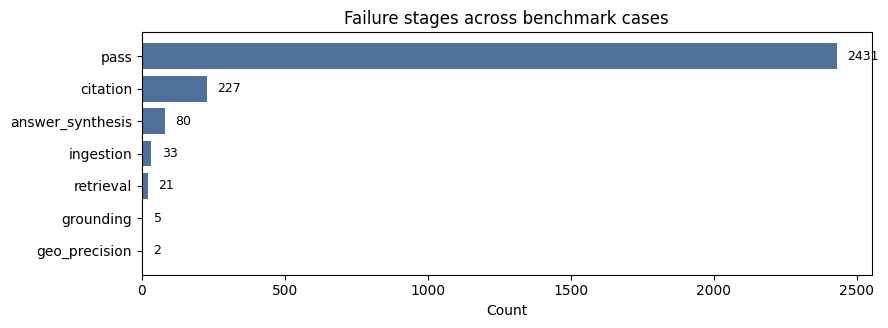

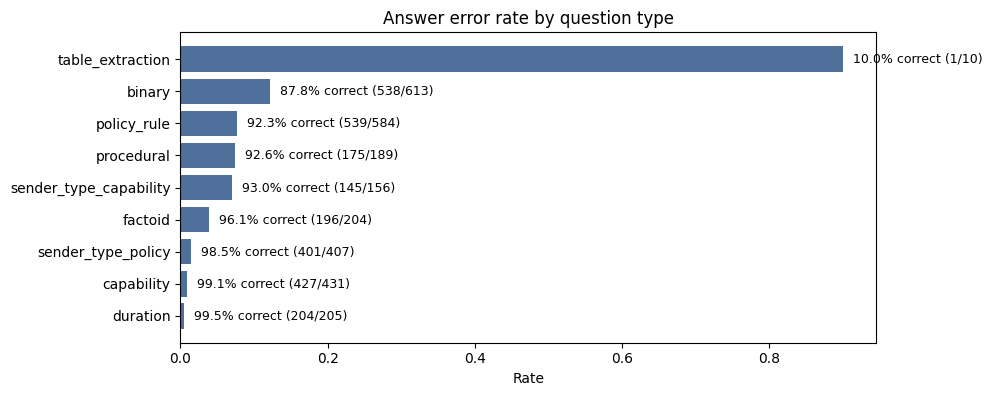

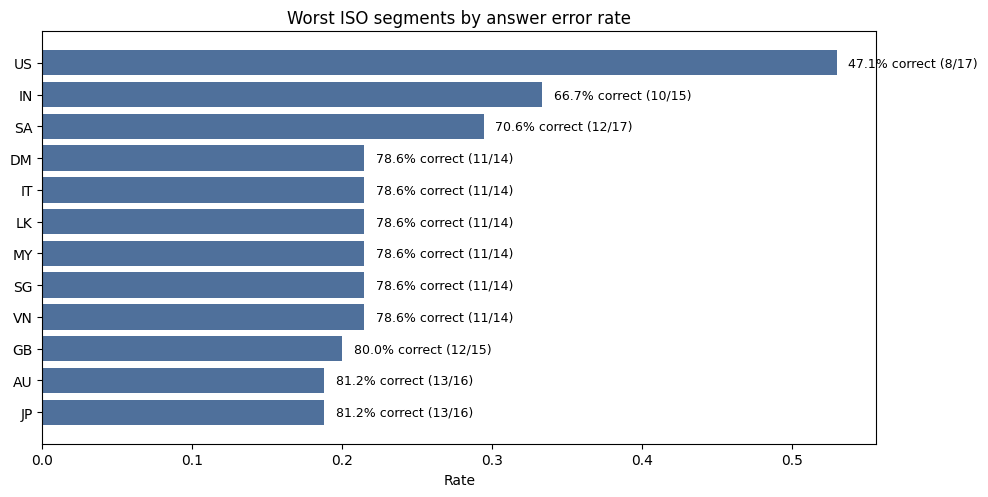

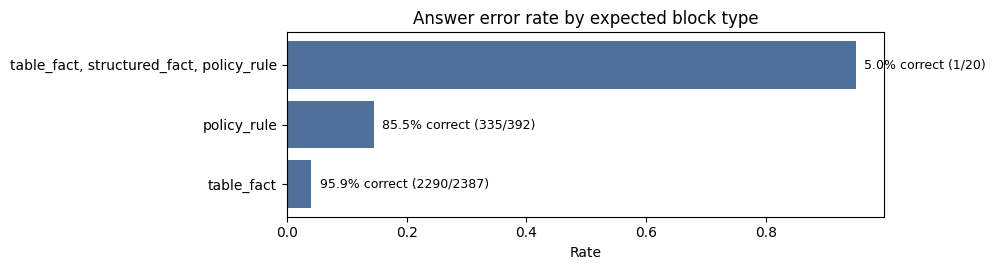

In [7]:
import matplotlib.pyplot as plt


def plot_barh(title, rows, value_key='value', label_key='label', width=9, row_height=0.34):
    rows = list(rows)
    labels = [str(row[label_key]) for row in rows]
    values = [float(row[value_key]) for row in rows]
    value_labels = [str(row.get('value_label', f'{value:g}')) for row, value in zip(rows, values)]
    fig_height = max(2.8, 1.0 + row_height * len(rows))
    fig, ax = plt.subplots(figsize=(width, fig_height))
    y_pos = range(len(rows))
    ax.barh(y_pos, values, color='#365c8d', alpha=0.88)
    ax.set_yticks(y_pos, labels)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Count' if max(values or [0]) > 1 else 'Rate')
    for y, value, label in zip(y_pos, values, value_labels):
        ax.text(value + (max(values or [1]) * 0.015), y, label, va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

failure_rows = [{'label': key, 'value': value, 'value_label': str(value)} for key, value in stage_counts.most_common()]

qt_rows = []
for label, counts in sorted(question_type.items(), key=lambda item: rate(item[1]['correct'], item[1]['total'])):
    correctness = rate(counts['correct'], counts['total'])
    qt_rows.append({'label': label, 'value': 1 - correctness, 'value_label': f'{correctness:.1%} correct ({counts["correct"]}/{counts["total"]})'})

iso_rows = []
for label, counts in sorted(iso.items(), key=lambda item: (rate(item[1]['correct'], item[1]['total']), -item[1]['total'], item[0]))[:12]:
    correctness = rate(counts['correct'], counts['total'])
    iso_rows.append({'label': label, 'value': 1 - correctness, 'value_label': f'{correctness:.1%} correct ({counts["correct"]}/{counts["total"]})'})

block_rows = []
for label, counts in sorted(block_type.items(), key=lambda item: rate(item[1]['correct'], item[1]['total'])):
    correctness = rate(counts['correct'], counts['total'])
    block_rows.append({'label': label, 'value': 1 - correctness, 'value_label': f'{correctness:.1%} correct ({counts["correct"]}/{counts["total"]})'})

analysis_summary = {
    'metrics': {metric: summary.get(metric) for metric in metrics},
    'failure_stage_counts': dict(stage_counts),
    'top_failure_reasons': reason_counts.most_common(10),
    'question_type_correctness': {
        label: {'correct': counts['correct'], 'total': counts['total'], 'rate': rate(counts['correct'], counts['total'])}
        for label, counts in sorted(question_type.items())
    },
    'worst_iso_segments': [
        {'iso_code': label, 'correct': counts['correct'], 'total': counts['total'], 'rate': rate(counts['correct'], counts['total'])}
        for label, counts in sorted(iso.items(), key=lambda item: (rate(item[1]['correct'], item[1]['total']), -item[1]['total'], item[0]))
        if counts['total'] >= 10
    ][:20],
}
(TABLE_DIR / 'failure_analysis_summary.json').write_text(json.dumps(analysis_summary, indent=2), encoding='utf-8')

with (TABLE_DIR / 'question_type_correctness.csv').open('w', encoding='utf-8', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=['question_type', 'correct', 'total', 'answer_correctness'])
    writer.writeheader()
    for label, counts in sorted(question_type.items(), key=lambda item: (rate(item[1]['correct'], item[1]['total']), item[0])):
        writer.writerow({'question_type': label, 'correct': counts['correct'], 'total': counts['total'], 'answer_correctness': rate(counts['correct'], counts['total'])})

with (TABLE_DIR / 'worst_iso_correctness.csv').open('w', encoding='utf-8', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=['iso_code', 'correct', 'total', 'answer_correctness'])
    writer.writeheader()
    for row in analysis_summary['worst_iso_segments']:
        writer.writerow({'iso_code': row['iso_code'], 'correct': row['correct'], 'total': row['total'], 'answer_correctness': row['rate']})

print(f'Wrote tables to {TABLE_DIR}')
plot_barh('Failure stages across benchmark cases', failure_rows)
plot_barh('Answer error rate by question type', qt_rows, width=10)
plot_barh('Worst ISO segments by answer error rate', iso_rows, width=10)
plot_barh('Answer error rate by expected block type', block_rows, width=10)

## Interpretation

Summary of findings: citation failures (`227`) outnumber synthesis failures (`109`) by about `2:1`. Binary questions are significantly weaker (`87.8%` correct after V1 templating) than the rest of the benchmark, and the US, IN, AE, SA, and LK segments underperform despite country match@1 staying near ceiling at `0.9950`. The V1 binary template improved answer correctness, but binary citation accuracy remained only `67.54%`, far behind capability (`100%`) and duration (`96.59%`), so the intervention helped the verdict more than the citation anchor.

Completed experiment: split binary questions by `row_key` and add a targeted yes/no answer template for support/registration rows. The V2 binary intervention reached `99.35%` binary correctness with `4` residual failures, all retrieval-stage.

Completed table follow-up: expand `table_extraction` from `10` to `50` table-style questions, then add row-aware retrieval aliases and cell-aware answer templates. The expanded table slice now reaches `88%` evidence hit rate and `82%` citation accuracy, clearing the `>80%` success targets. Remaining table failures are multi-intent questions and source-coverage gaps, especially where a prompt asks for support plus provisioning time or expects handset-delivery/default-sender rows that are not cleanly normalized.

Next experiment: attack exact-value duration answers and remaining citation anchoring failures without weakening the now-strong binary and table segments.

## Next Experiment: Binary Question Template Experiment

Hypothesis: binary question correctness will improve from `82.7%` to at least `90%` if yes/no answers are generated with a dedicated template that forces three steps: identify the relevant table row, decide yes/no from that row only, and cite the exact evidence. This is the strongest next product experiment because it closes the DS loop: measured segment gap → causal hypothesis → targeted intervention → explicit success metric.

Success metric: rerun `benchmarks/country_regressions.json` and compare binary correctness, citation accuracy, and overall answer correctness before and after the template. The change should be promoted only if binary correctness improves without lowering citation accuracy. Track binary citation accuracy separately because the V1 template improved correctness more than citation anchoring.